In [1]:
from dataclasses import dataclass
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel
from transformers import GPT2Tokenizer
from torch import device
import tiktoken
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset
from matplotlib.pyplot import step

/home/xerneas/projects/makemore/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
print(len(text))
data = text
print(data[:100])

1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [3]:
enc = tiktoken.get_encoding("gpt2")
tr_tokens = enc.encode(data[:1000000])
tst_tokens = enc.encode(data[1000000:])

torch.set_float32_matmul_precision('high')

# print(tr_tokens[:10])
# print(tst_tokens[:10])
T = 32
B = 16

device = 'cuda' if torch.cuda.is_available() else 'cpu'
buf = torch.tensor(tr_tokens, device=device, dtype=torch.long)

N = (len(buf) - 1) // T
x = buf[:N*T].view(N, T)
y = buf[1:1+N*T].view(N, T)
# print(x.shape)
tr_ds = TensorDataset(x, y)

tr_loader = torch.utils.data.DataLoader(
    tr_ds,
    batch_size=B, 
    shuffle=True,
)

buf2 = torch.tensor(tst_tokens, device=device, dtype=torch.long)
N2 = (len(buf2) - 1) // T
x2 = buf2[:N2*T].view(N2, T)
y2 = buf2[1:1+N2*T].view(N2, T)

tst_ds = TensorDataset(x2, y2)
tst_loader = torch.utils.data.DataLoader(
    tst_ds,
    batch_size=B,
    shuffle=True,
)

In [4]:
max_lr = 6e-4
min_lr = max_lr * 0.1

def configure_optimizers(model, weight_decay, lr):
    param_dict = {n: p for n, p in model.named_parameters() if p.requires_grad}
    decay   = [p for p in param_dict.values() if p.dim() >= 2]   # weights, embeddings
    nodecay = [p for p in param_dict.values() if p.dim() <  2]   # biases, layernorms
    groups = [
        {'params': decay,   'weight_decay': weight_decay},
        {'params': nodecay, 'weight_decay': 0.0},
    ]
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.95), eps=1e-8, fused=True)


In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, config.n_embd * 3)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.n_layer = config.n_layer
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))
        nn.init.normal_(self.c_proj.weight, mean=0.0, std=0.02/math.sqrt(2 * self.n_layer))

    def forward(self, x):
        B,T,C = x.size()
        qkv = self.c_attn(x)
        q,k,v = qkv.split(self.n_embd, dim = 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1,2) # B, nh, T, hs
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1,2) # B, nh, T, hs
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1,2) # B, nh, T, hs
        # B, nh, T, hs @ B, nh, hs, T -> B, nh, T, T
        # attn = q @ k.transpose(-2,-1) * (1.0 / math.sqrt(k.size(-1)))
        # attn = attn.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        # attn = F.softmax(attn, dim=-1)
        # # B, nh, T, T @ B, nh, T, hs -> B, nh, T, hs
        # out = attn @ v

        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        # B, nh, T, hs -> B, T, nh, hs
        out = out.transpose(1,2).contiguous().view(B,T,C) # B, T, C
        out = self.c_proj(out)
        return out



In [6]:
class MLP(nn.Module): #feedforward
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

In [7]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [8]:
@dataclass
class GPT2Config:
    block_size: int = 1024
    vocab_size: int = 50257
    n_layer: int = 12
    n_embd: int = 768
    n_head: int = 12

In [9]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias) #bias does not init to 0 be default in torch
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
    # @classmethod
    # def from_pretrained(cls, model_name):
    #     pretrained = GPT2LMHeadModel.from_pretrained(model_name)
    #     cfg = pretrained.config
    #     config = GPT2Config(
    #         block_size=1024,
    #         vocab_size=cfg.vocab_size,
    #         n_layer=cfg.n_layer,
    #         n_embd=cfg.n_embd,
    #         n_head=cfg.n_head,
    #     )
    #     model = cls(config)

    #     sd       = model.state_dict()
    #     sd_hf    = pretrained.state_dict()

    #     # skip our mask buffer(s); HF doesn't have them
    #     keys = [k for k in sd_hf if not k.endswith('.attn.bias') and not k.endswith('.attn.masked_bias')]
    #     transposed = ('attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight')

    #     for k in keys:
    #         if any(k.endswith(t) for t in transposed):
    #             assert sd_hf[k].shape[::-1] == sd[k].shape
    #             with torch.no_grad():
    #                 sd[k].copy_(sd_hf[k].t())          # Conv1D -> Linear: transpose
    #         else:
    #             assert sd_hf[k].shape == sd[k].shape
    #             with torch.no_grad():
    #                 sd[k].copy_(sd_hf[k])
    #     return model


    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)   # token + position embeddings
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)                                    # (B, T, vocab_size)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss
        

In [10]:
# model = GPT.from_pretrained('gpt2')
# model.to(device)
# model.eval()

# tok = GPT2Tokenizer.from_pretrained('gpt2')
# idx = tok.encode("Hello, I'm a language model,", return_tensors='pt').to(device)
# # torch.manual_seed(42)
# for _ in range(30):
#     with torch.no_grad():
#         logits, _ = model(idx)      # your forward returns (logits, loss)
#     logits = logits[:, -1, :]       # last position
#     probs = F.softmax(logits, dim=-1)
#     nxt = torch.multinomial(probs, 1)
#     idx = torch.cat([idx, nxt], dim=1)

# print(tok.decode(idx[0]))

In [11]:
model = GPT(GPT2Config(vocab_size=50304))
model.to(device)


epochs = 10
step = 0

optimizer = configure_optimizers(model, weight_decay=0.1, lr=max_lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=max_lr,
    total_steps=epochs * len(tr_loader),
    pct_start=0.05,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,   
)

model = torch.compile(model)
model.train()
t_loss = []


for _ in range(epochs):
    e_loss = []
    for x,y in tr_loader:
        optimizer.zero_grad()
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(x.to(device), y.to(device))
        loss.backward()
        # norm = torch.clip_grad_norm_(model.parameters(), 1.0)
        e_loss.append(loss.item())
        optimizer.step()
        scheduler.step()
        step+=1
    print(f"Epoch {_+1}/{epochs} - Loss: {sum(e_loss)/len(e_loss)}")
    t_loss.append(sum(e_loss)/len(e_loss))

W0714 03:11:20.122000 292761 torch/_inductor/utils.py:1717] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/10 - Loss: 5.845292464405501
Epoch 2/10 - Loss: 4.727600677078273
Epoch 3/10 - Loss: 4.48427165203354
Epoch 4/10 - Loss: 4.314061861865374
Epoch 5/10 - Loss: 4.152713698594749
Epoch 6/10 - Loss: 3.9774323478847946
Epoch 7/10 - Loss: 3.7751624426063226
Epoch 8/10 - Loss: 3.5531704608274968
Epoch 9/10 - Loss: 3.345749711503788
Epoch 10/10 - Loss: 3.212472155386088


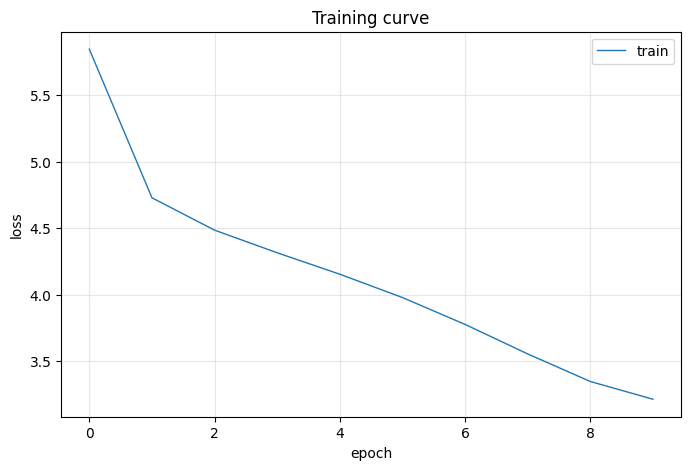

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(t_loss)), t_loss, label='train', linewidth=1)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
model.eval()
with torch.no_grad():
    tr_loss = []
    tst_loss = []
    for x, y in tr_loader:
        logits, loss = model(x.to(device), y.to(device))
        tr_loss.append(loss.item())
    for x, y in tst_loader:
        logits, loss = model(x.to(device), y.to(device))
        tst_loss.append(loss.item())

    print(f"Train Loss: {sum(tr_loss) / len(tr_loss)}")
    print(f"Test Loss: {sum(tst_loss) / len(tst_loss)}")


Train Loss: 3.1818090924600355
Test Loss: 4.937904429762331


In [18]:
model.eval()
inp = 'Shakespeare:'
tok = enc.encode(inp)

for i in range(10):
    out = []
    context = tok + [0] * (32 - len(tok))
    for _ in range(50):
        logits, loss = model(torch.tensor([context], device=device))
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append((ix))
    print(enc.decode(out))



JULIET:
It was that citizens where it isVOLcius sir, if he stay'd here.
3 KING HENRY VI

KING HENRY VI:
 thrust not the king at sea! here shall


A sep crorician:
Theorns I may mean thee with the Duke of Norfolk!

KING EDWARD IV:
O good but let thee love my prithee see thee hence;
And what dost thou make


LORD F motions:
Madam, most fashion'd with it.

HORTENSIO:
 loving word, SigniorLARTIUS:
There shall be itself
Than am a goldenWeak court's mad




ROMEO:
So reven goes so, Bion Verona,
Why didst thou in hither? and God bid me thee joy,
ThatSet their pl immortal women back with my living leave?

BENVOL
 forfeit tell thee!

L theirvenient voice: stolen your asMore than your arg
 sense own wool of the hanging: he How painted,
 guilt s coat his corn or painted! puny be done?

LEONTES:

 scandal through the dissolve and leth're alive.

PRINCE:
How look thee, cousin, old foul wrongs!

First Watchman:
O, Kingitor! that other love!
Will they be ignorance to


FLORIZEL:
eous, what different there shall be? but finger.
Go ne'er till greater remembranceKE:
Where is our arms is character not that England, pass?
We haveught Clarence writes, they
 what aeed
 looks have prophet strike with the crack- thrust'd!

First constantener:
 budest orary, thouFaith, have you get met you all, have I flament
ForThe imped proclamation had been precedent
his volume
bury might have me frame one that gave you,
I cannot seek within their guilt of the Capulet;